In [26]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import math
import openpyxl
from pathlib import Path
import datetime
import re
import numpy as np

In [27]:
files = os.listdir("classified_datasets/traffic/anpr_excel")
files = [f for f in files if f.endswith(".csv")]
files

['Bath ANPR anonymised data 10th Nov 2017.csv',
 'Bath ANPR anonymised data 11th Nov 2017.csv',
 'Bath ANPR anonymised data 12th Nov 2017.csv',
 'Bath ANPR anonymised data 13th Nov 2017.csv',
 'Bath ANPR anonymised data 1st Nov 2017.csv',
 'Bath ANPR anonymised data 2nd Nov 2017.csv',
 'Bath ANPR anonymised data 31st Oct 2017.csv',
 'Bath ANPR anonymised data 3rd Nov 2017.csv',
 'Bath ANPR anonymised data 4th Nov 2017.csv',
 'Bath ANPR anonymised data 5th Nov 2017.csv',
 'Bath ANPR anonymised data 6th Nov 2017.csv',
 'Bath ANPR anonymised data 7th Nov 2017.csv',
 'Bath ANPR anonymised data 8th Nov 2017.csv']

In [28]:
comb = pd.DataFrame()
for i in files:
    df = pd.read_csv(f"classified_datasets/traffic/anpr_excel/{i}")
    comb = pd.concat([comb, df], ignore_index=True)

In [29]:
comb["timestamp"] = pd.to_datetime(comb["timestamp"])

In [30]:
comb.sort_values("timestamp", inplace=True)
comb.reset_index(drop=True, inplace=True)
comb["Confidence"] = comb["Confidence"].astype(int)
comb.drop(columns=["Unique vehicle reference", "Vehicle Registration Plate", "Country"], inplace=True, errors="ignore")
comb = comb[comb["Confidence"] > 0]
comb.reset_index(drop=True, inplace=True)
comb

,timestamp,Confidence,Site Reference,Direction
0,2017-10-31 00:03:27,100,16,E
1,2017-10-31 00:06:41,100,32,N
2,2017-10-31 00:07:43,99,13,N
3,2017-10-31 00:09:02,99,17,E
4,2017-10-31 00:09:39,30,15,E
...,...,...,...,...
3721239,2017-11-13 23:59:48,99,13,N
3721240,2017-11-13 23:59:54,100,21,S
3721241,2017-11-13 23:59:55,99,7,W
3721242,2017-11-13 23:59:58,100,20,W


In [31]:
sensor_names = pd.read_csv("classified_datasets/traffic/location_names.csv")
sensor_names.drop(columns=["name", "id", "direction", "longitude", "latitude"], inplace=True, errors="ignore")
sensor_names.drop_duplicates(inplace=True)
sensor_names.reset_index(drop=True, inplace=True)
comb["sensor_name"] = comb["Site Reference"].map(sensor_names.set_index("location_id")["sensor_name"])
comb.drop(columns=["sensor_name", "Confidence", "Direction"], inplace=True, errors="ignore")

In [32]:
by_sensor_id = {id_val: group for id_val, group in comb.groupby('Site Reference')}

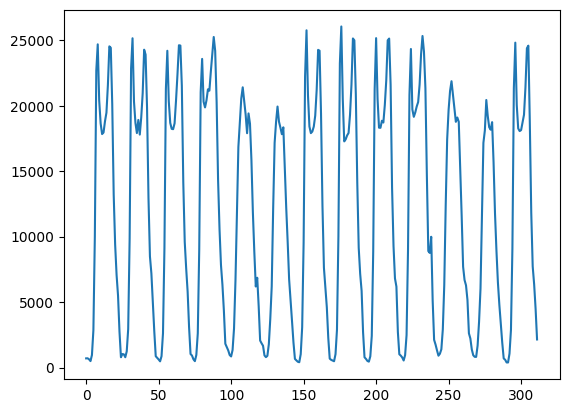

In [33]:
quarterly_count = comb.groupby(comb['timestamp'].dt.floor('1h')).size()

import matplotlib.pyplot as plt
plt.plot(quarterly_count.values)

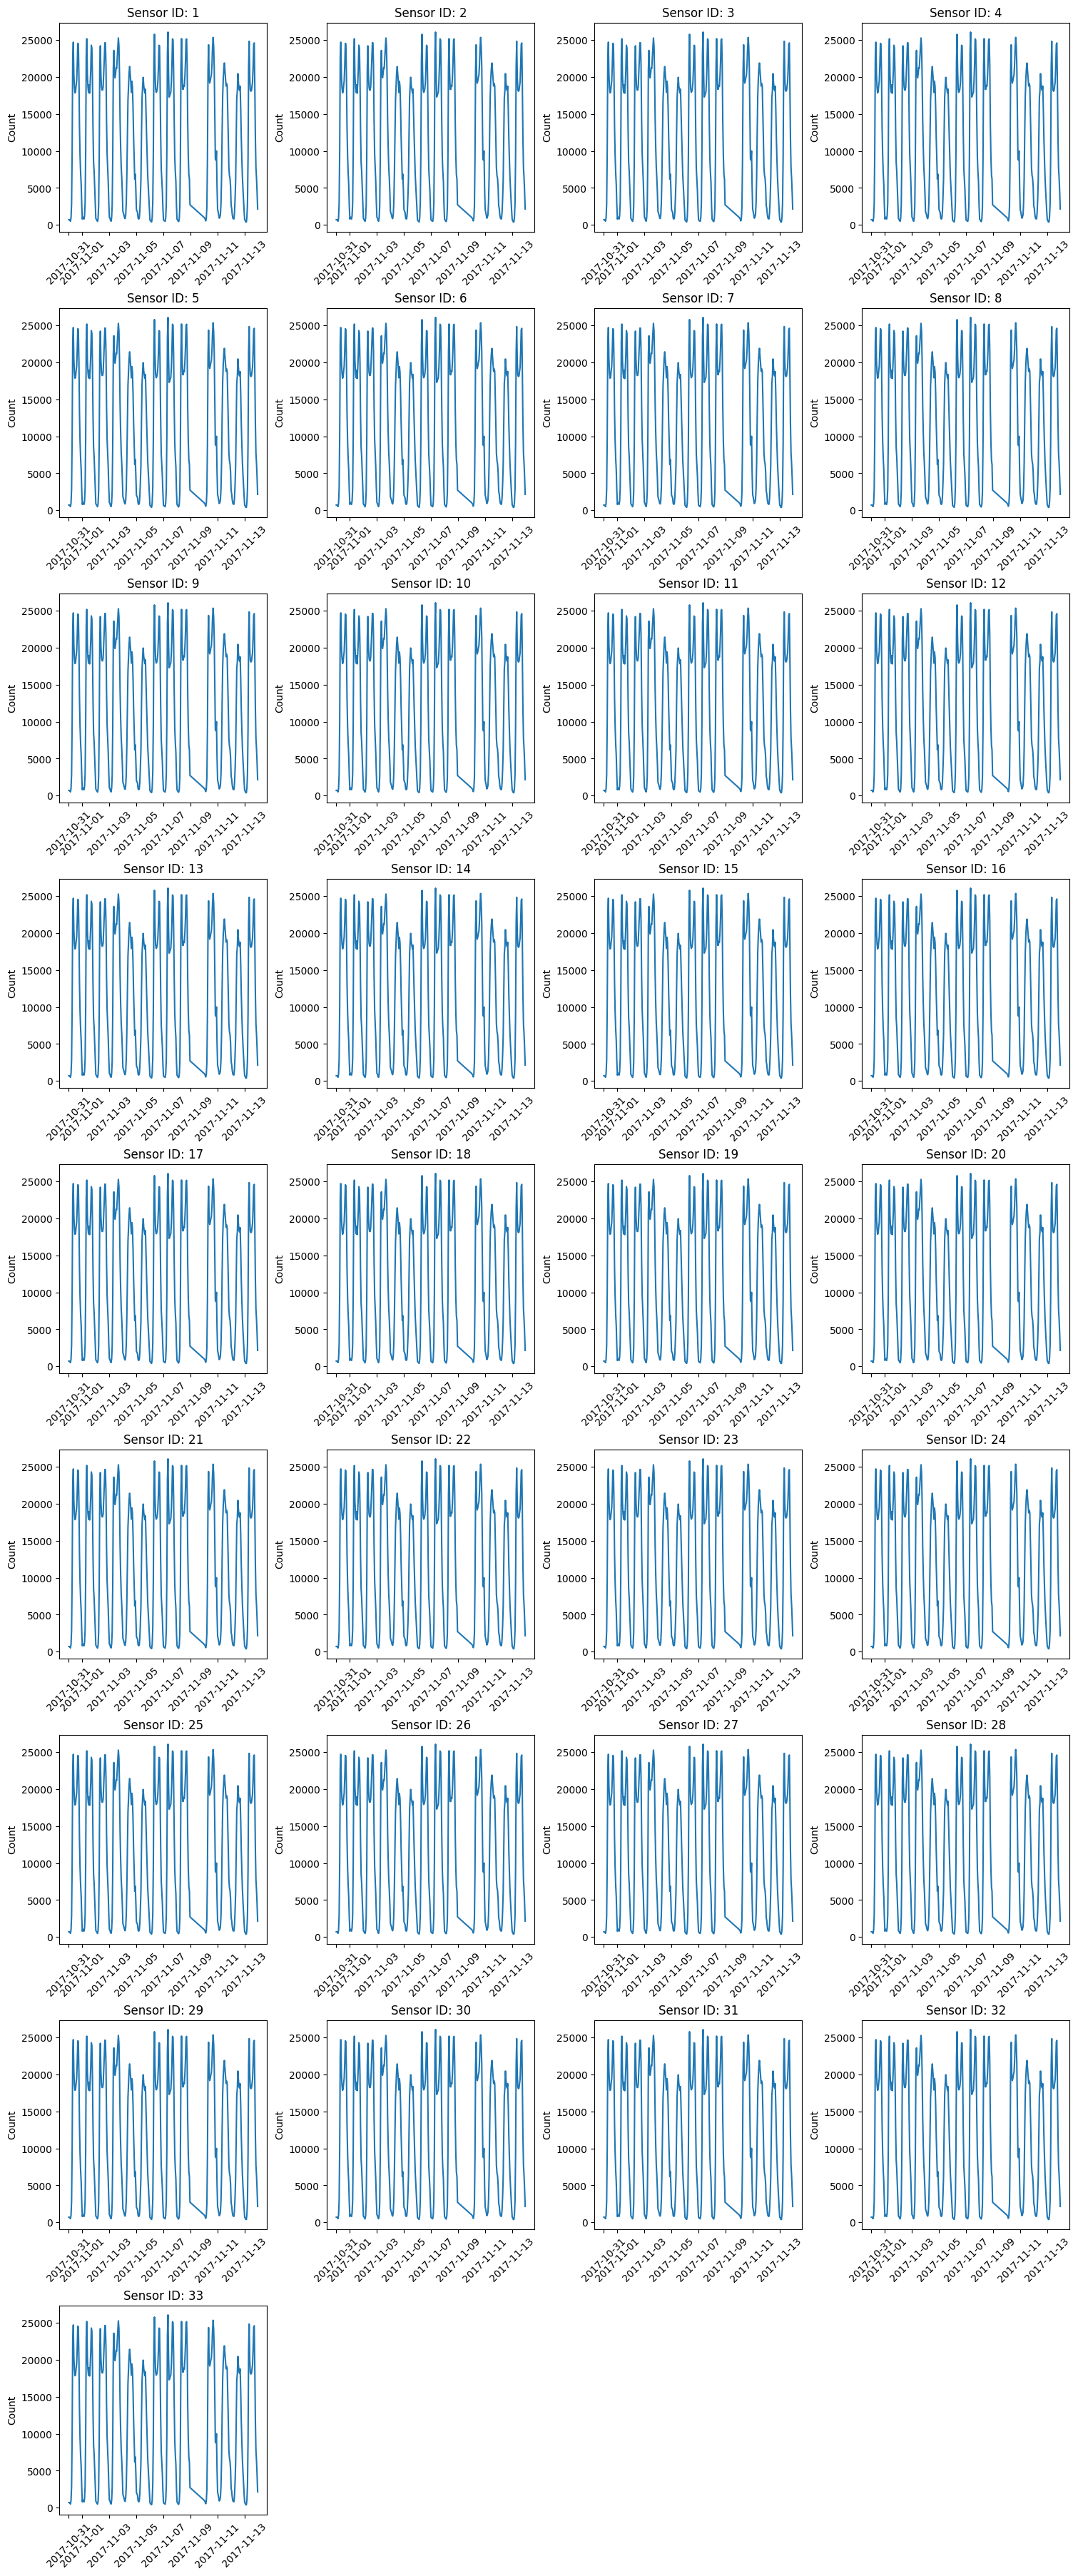

In [34]:
num_sensors = len(by_sensor_id)
cols = 4  
rows = math.ceil(num_sensors / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), constrained_layout=True)
axes = axes.flatten()

for i, (sensor_id, data) in enumerate(by_sensor_id.items()):    
    axes[i].plot(quarterly_count.index, quarterly_count.values)
    axes[i].set_title(f"Sensor ID: {sensor_id}")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()

# sector data and atc to do

In [35]:
class ExcelTrafficParser:
    """Parse traffic ATC Excel files with flexible sheet names and counts"""
    
    def __init__(self, filepath):
        self.filepath = filepath
        self.wb = openpyxl.load_workbook(filepath)
        self.site_info = {}
        
    def extract_site_metadata(self, sheet):
        """Extract site information from first few rows"""
        rows = list(sheet.iter_rows(values_only=True))
        metadata = {
            'site_no': rows[0][1] if rows[0][1] else None,
            'site_name': rows[1][0] if rows[1][0] else None,
            'channel': self._extract_channel(rows[2]),
        }
        return metadata
    
    def _extract_channel(self, row):
        directions = ['east', 'north', 'west', 'south', 'bound']        
        for cell in row:
            if cell and isinstance(cell, str):
                cell_lower = cell.lower()
                if any(dir_word in cell_lower for dir_word in directions):
                    return cell.strip().lower().strip("bound")
        return None
    
    def parse_sheet(self, sheet_name):
        """Parse single sheet, excluding totals"""
        ws = self.wb[sheet_name]
        rows = list(ws.iter_rows(values_only=True))
        metadata = self.extract_site_metadata(ws)        
        headers = rows[5]
        # Exclude last 2 columns (5-Day Av, 7-Day Av)
        if headers:
            headers = headers[:-2]
        
        data = []
        for row in rows[6:]:
            if row[0] is not None:
                clean_row = row[:-2]
                data.append(clean_row)
        
        df = pd.DataFrame(data, columns=headers)
        df.columns = ['Time'] + [f'Day_{i}' if isinstance(h, datetime.datetime) 
                                  else str(h) for i, h in enumerate(headers[1:])]
        df['Sheet'] = sheet_name
        return df
    
    def keep_essential_rows(self, df):
        mask = df["Time"].apply(lambda x: isinstance(x, datetime.time))
        df = df[mask].reset_index(drop=True)
        df = df[(df.index // 24) % 3 == 2]
        return df

    def to_datetime(self, df):
        df["Sheet"] = df["Sheet"].apply(lambda x: x.split()[1:])
        df["Date"] = df["Sheet"].apply(lambda x: datetime.date(int(x[2]), int(x[1]), int(x[0])))
        df["datetime"] = df.apply(lambda x: datetime.datetime.combine(x["Date"], x["Time"]),axis=1)
        df.drop(columns=["Sheet"], inplace=True)
        return df
    
    def wide_to_long(self, df):
        day_cols = [col for col in df.columns if col.startswith("Day_")]
        df = df.melt(
            id_vars=["datetime"],
            value_vars=day_cols,
            var_name="horizon",
            value_name="count"
        )
        df["horizon_num"] = df["horizon"].str.extract("(\d+)").astype(int)

        # Add the horizon offset to the datetime
        df["datetime"] = df["datetime"] + pd.to_timedelta(df["horizon_num"], unit="D")

        df.drop(columns=["horizon", "horizon_num"], inplace=True)
        return df

    def parse_all_sheets(self):
        """Parse all sheets from workbook"""
        all_data = []
        for sheet_name in self.wb.sheetnames:
            df = self.parse_sheet(sheet_name)
            all_data.append(df)
            print(f"✓ Parsed: {sheet_name}", self.filepath)

        df = pd.concat(all_data, ignore_index=True) if all_data else None
        df = self.keep_essential_rows(df)
        df = self.to_datetime(df)
        
        df["date"] = df["Date"].copy()
        df = self.wide_to_long(df)
        df = df.sort_values("datetime").reset_index(drop=True)
        return df

<>:71: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid escape sequence '\d'
C:\Users\lucch\AppData\Local\Temp\ipykernel_9588\2188351905.py:71: SyntaxWarning: invalid escape sequence '\d'
  df["horizon_num"] = df["horizon"].str.extract("(\d+)").astype(int)


In [36]:
by_sensor_id[1]

,timestamp,Site Reference
19,2017-10-31 00:14:07,1
40,2017-10-31 00:15:45,1
131,2017-10-31 00:20:21,1
141,2017-10-31 00:20:48,1
187,2017-10-31 00:23:38,1
...,...,...
3721034,2017-11-13 23:50:47,1
3721057,2017-11-13 23:51:50,1
3721064,2017-11-13 23:52:04,1
3721180,2017-11-13 23:56:44,1


In [37]:
for i in by_sensor_id:
    by_sensor_id[i] = pd.DataFrame({"timestamp": by_sensor_id[i].groupby(by_sensor_id[i]['timestamp'].dt.floor('1h')).size().index, "count": by_sensor_id[i].groupby(by_sensor_id[i]['timestamp'].dt.floor('1h')).size().values}, columns=["timestamp", "count"])

In [38]:
files = os.listdir("classified_datasets/traffic/atc")
func = lambda f: f.endswith(".xlsx")
files = list(filter(func, files))
for i in files:
    parser = ExcelTrafficParser(f"classified_datasets/traffic/atc/{i}")
    df = parser.parse_all_sheets()
    site_ref = int(i.split("_")[0])
    cur_df = by_sensor_id[site_ref]
    by_sensor_id[site_ref] = pd.concat([cur_df, df], axis=0)

✓ Parsed: Volume 23 10 2017 classified_datasets/traffic/atc/12_Lansdown Road.xlsx
✓ Parsed: Volume 30 10 2017 classified_datasets/traffic/atc/12_Lansdown Road.xlsx
✓ Parsed: Volume 23 10 2017 classified_datasets/traffic/atc/13_Camden Road.xlsx
✓ Parsed: Volume 30 10 2017 classified_datasets/traffic/atc/13_Camden Road.xlsx
✓ Parsed: Volume 23 10 2017 classified_datasets/traffic/atc/14_London Road.xlsx
✓ Parsed: Volume 30 10 2017 classified_datasets/traffic/atc/14_London Road.xlsx
✓ Parsed: Volume 23 10 2017 classified_datasets/traffic/atc/16_north Road.xlsx
✓ Parsed: Volume 30 10 2017 classified_datasets/traffic/atc/16_north Road.xlsx
✓ Parsed: Volume 23 10 2017 classified_datasets/traffic/atc/17_Bathwick Hill.xlsx
✓ Parsed: Volume 30 10 2017 classified_datasets/traffic/atc/17_Bathwick Hill.xlsx
✓ Parsed: Volume 23 10 2017 classified_datasets/traffic/atc/19_prior park road.xlsx
✓ Parsed: Volume 30 10 2017 classified_datasets/traffic/atc/19_prior park road.xlsx
✓ Parsed: Volume 23 10 201

In [39]:
for i in by_sensor_id:
    if len(by_sensor_id[i].columns) > 2:
        mask = by_sensor_id[i]["timestamp"].isna()
        by_sensor_id[i].loc[mask, "timestamp"] = by_sensor_id[i].loc[mask, "datetime"]
        by_sensor_id[i].drop(columns=["datetime"], inplace=True)

In [ ]:
df = by_sensor_id[12]
df

,timestamp,count
0,2017-10-31 00:00:00,4
1,2017-10-31 01:00:00,7
2,2017-10-31 02:00:00,8
3,2017-10-31 03:00:00,4
4,2017-10-31 04:00:00,12
...,...,...
331,2017-11-05 19:00:00,403
332,2017-11-05 20:00:00,211
333,2017-11-05 21:00:00,137
334,2017-11-05 22:00:00,96
